In [1]:
import numpy as np
import math

In [2]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    for n in nodes:
        dot.node(name=str(id(n)), label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [3]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0.0
    self._backward = lambda: None # Initialize _backward here
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other),'+')
    def _backward():
      self.grad  += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other),'*')
    def _backward():
      self.grad  += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += (other * self.data**(other-1)) * out.grad
    out._backward = _backward

    return out

  def __radd__(self, other): # other + self
        return self + other

  def __truediv__(self, other):
    return self * other**-1

  def __rmul__(self, other):
    return self * other

  def __neg__(self):
    return self * (-1)

  def __sub__(self, other):
    return self + (-other)

  def tanh(self):
    x = self.data
    t = (np.exp(2*x) - 1)/(np.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad += (1 - t**2) * out.grad
    out._backward = _backward

    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ),'exp')
    def _backward():
        self.grad += out.data * out.grad
    out._backward = _backward # Corrected: Moved this line out of _backward function
    return out

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)

    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

  def __repr__(self):
    return f"Value(data={self.data})"

In [4]:
a = Value(2.0)
b = Value(4.0)
2*a

Value(data=4.0)

In [5]:
a=Value(2, label='a')
b=Value(-3, label='b')
c=Value(10, label='c')
e=a*b; e.label='e'
d=e+c; d.label='d'
f = Value(-2, label='f')
L = d*f; L.label='L'

L

Value(data=-8)

In [6]:
L.grad = 1
d.grad = -2.0
f.grad = 4
c.grad = -2
e.grad = -2
a.grad = 6
b.grad = -4

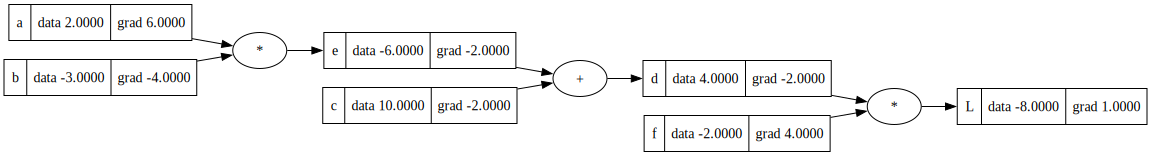

In [7]:
draw_dot(L)

In [8]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a*b
d = e+c
L = d*f
print(L.data)

-7.286496


In [9]:
def lol():
  h = 0.001

  a=Value(2, label='a')
  b=Value(-3, label='b')
  c=Value(10, label='c')
  e=a*b; e.label='e'
  d=e+c; d.label='d'
  f = Value(-2, label='f')
  L = d*f; L.label='L'

  L1 = L.data

  a=Value(2, label='a')
  b=Value(-3, label='b')
  b.data += h
  c=Value(10, label='c')
  e=a*b; e.label='e'
  d=e+c; d.label='d'
  f = Value(-2, label='f')
  L = d*f; L.label='L'

  L2 = L.data

  print((L2-L1)/h)

In [10]:
lol()

-3.9999999999995595


In [11]:
# input x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

o.backward()

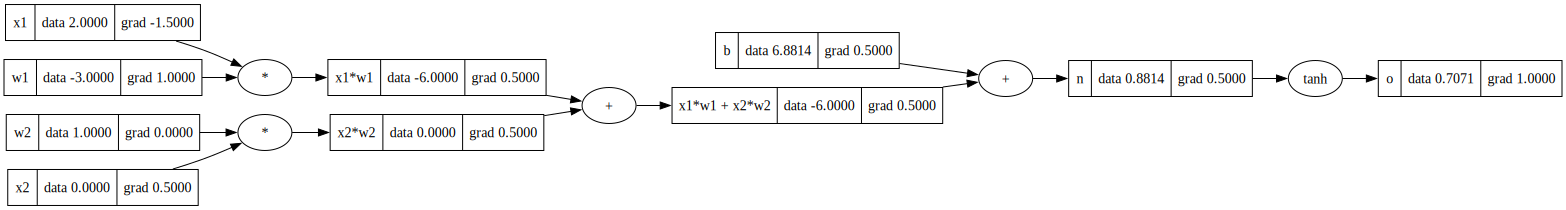

In [12]:
draw_dot(o)

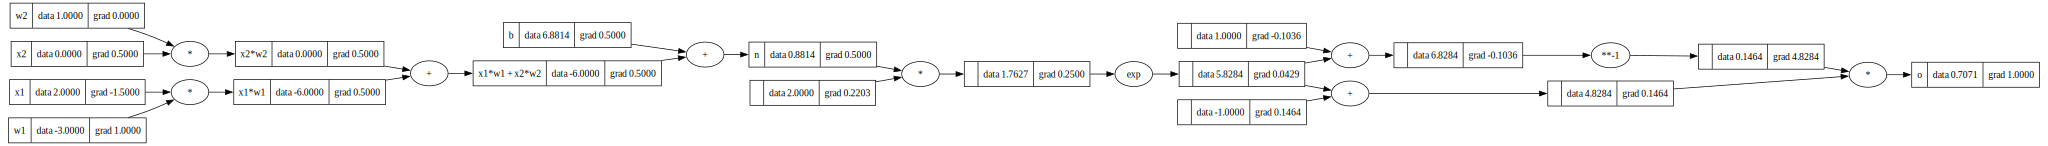

In [13]:
# input x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ------
e = (2*n).exp()
o = (e - 1) / (e + 1)
# ------

#
o.label = 'o'
o.backward()
draw_dot(o)


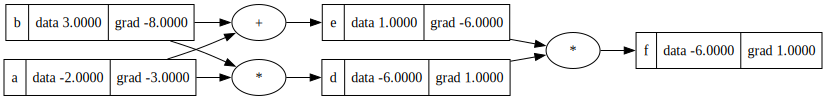

In [14]:
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b ; d.label='d'
e = a + b ; e.label='e'
f = d * e ; f.label='f'

f.backward()
draw_dot(f)

In [23]:
import torch

In [24]:
x1 = torch.Tensor([2.0]).double()   ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()   ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()  ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()  ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [25]:
class Neuron:

  def __init__(self, nin):
    # Fix: Convert generator to a list so it can be iterated multiple times
    self.w = [Value(np.random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(np.random.uniform(-1,1))

  def __call__(self, x):
    act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)

    out = act.tanh()
    return out

  def parameters(self):
    return self.w + [self.b]

class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP:

  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [26]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])

n(x)

Value(data=-0.724552097707521)

In [27]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0]



In [28]:
for k in range(20):
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.05 * p.grad

  print(k, loss.data)


0 6.435390144467555
1 4.737735635538073
2 3.2833638597264834
3 1.8262823571244
4 0.8478734880836915
5 0.45091977860138577
6 0.283442506308847
7 0.20014461279808687
8 0.1522662952861337
9 0.12176687546129758
10 0.1008651473122933
11 0.08575062135792576
12 0.07436550928489252
13 0.06551105117626037
14 0.0584458304003401
15 0.05268861201576211
16 0.04791440161441618
17 0.04389632896742586
18 0.04047151698844405
19 0.03752018546178032


In [29]:
ypred

[Value(data=0.9716821057089974),
 Value(data=-0.9120132317408784),
 Value(data=-0.8687876341286445),
 Value(data=0.8915568075974287)]

In [30]:
ypred

[Value(data=0.9716821057089974),
 Value(data=-0.9120132317408784),
 Value(data=-0.8687876341286445),
 Value(data=0.8915568075974287)]